# EuroSAT-MS Data Exploration

## 1. Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path

## 2. Locate dataset and select one sample image

In [5]:
data_dir = Path("../data/EuroSAT_MS/Forest")  
tif_files = list(data_dir.rglob("*.tif"))

print(f"Number of .tif files found: {len(tif_files)}")

sample_path = tif_files[0]
print("Sample file:", sample_path)

Number of .tif files found: 3000
Sample file: ../data/EuroSAT_MS/Forest/Forest_2230.tif


## 3. Read the multispectral GeoTIFF image

In [6]:
with rasterio.open(sample_path) as src:
    img = src.read()
    profile = src.profile

print("Image shape:", img.shape)
print("Data type:", img.dtype)
print("Raster profile:")
print(profile)

Image shape: (13, 64, 64)
Data type: uint16
Raster profile:
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 64, 'height': 64, 'count': 13, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 34N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",21],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32634"]]'), 'transform': Affine(9.99609868365168, 0.0, 669210.3057983121,
       0.0, -9.985523545152093, 6082324.332088696), 'blockxsize': 64, 'blockysize': 4, 'tiled': False, 'interleave': 'pixel'}


## 4. Extract the class label

In [7]:
label = sample_path.parent.name
print("Label:", label)

Label: Forest


## 5. Inspect per-band statistics

In [8]:
print("Per-band statistics:")
for b in range(img.shape[0]):
    band = img[b]
    print(
        f"Band {b+1:02d} | "
        f"min={band.min()}, "
        f"max={band.max()}, "
        f"mean={band.mean():.2f}, "
        f"std={band.std():.2f}"
    )

Per-band statistics:
Band 01 | min=1124, max=1175, mean=1147.95, std=12.91
Band 02 | min=749, max=935, mean=828.56, std=22.80
Band 03 | min=553, max=835, mean=668.34, std=32.86
Band 04 | min=336, max=671, mean=436.60, std=48.36
Band 05 | min=540, max=825, mean=668.15, std=58.94
Band 06 | min=1315, max=1790, mean=1558.06, std=64.85
Band 07 | min=1610, max=2296, mean=1902.75, std=95.18
Band 08 | min=1229, max=2792, mean=1811.00, std=147.29
Band 09 | min=424, max=536, mean=467.50, std=16.84
Band 10 | min=7, max=11, mean=8.69, std=0.86
Band 11 | min=670, max=1421, mean=1004.97, std=181.88
Band 12 | min=282, max=704, mean=457.51, std=105.39
Band 13 | min=1758, max=2579, mean=2108.19, std=102.48


## 6. Normalization function for visualization

In [ ]:
def normalize_band(x, lower=2, upper=98):
    x = x.astype("float32")
    lo, hi = np.percentile(x, (lower, upper))
    x = np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)
    return x

## 7. Visualize an RGB composite image

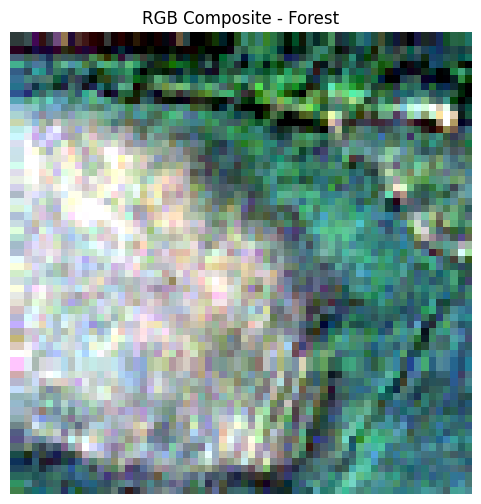

In [16]:
r = normalize_band(img[3])   # B04 = RED
g = normalize_band(img[2])   # B03 = GREEN
b = normalize_band(img[1])   # B02 = BLUE

rgb = np.stack([r, g, b], axis=-1)

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title(f"RGB Composite - {label}")
plt.axis("off")
plt.show()

## 8. Define Sentinel-2 band names

In [12]:
band_names = [
    "B01", "B02", "B03", "B04", "B05", "B06", "B07",
    "B08", "B8A", "B09", "B10", "B11", "B12"
]

## 9. Visualize all 13 spectral bands

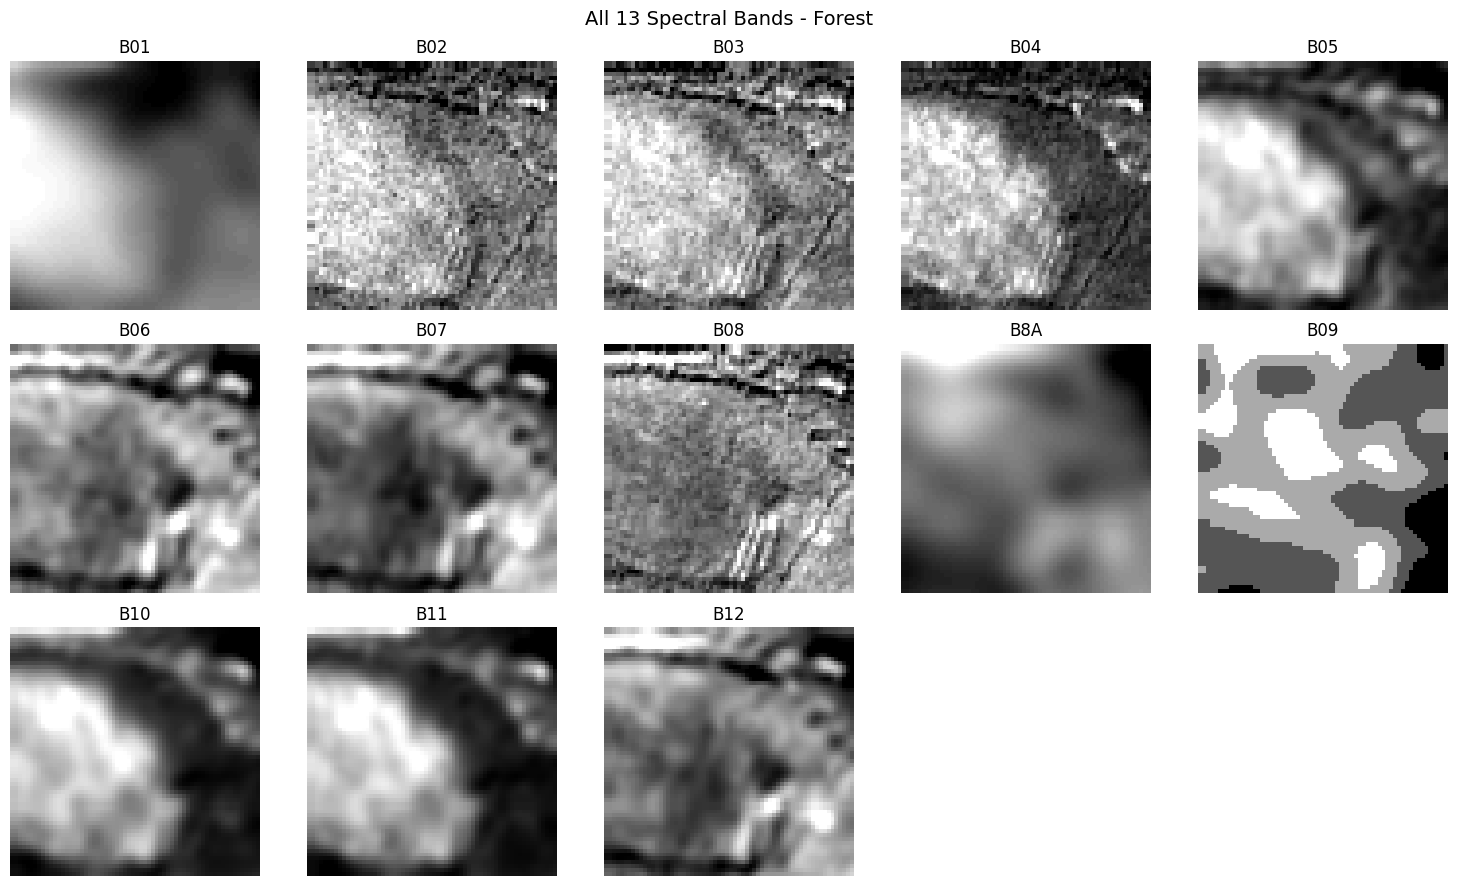

In [13]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i in range(len(axes)):
    ax = axes[i]
    if i < img.shape[0]:
        ax.imshow(normalize_band(img[i]), cmap="gray")
        ax.set_title(band_names[i])
    ax.axis("off")

plt.suptitle(f"All 13 Spectral Bands - {label}", fontsize=14)
plt.tight_layout()
plt.show()

## Observations

- Each EuroSAT-MS sample is a 13-channel multispectral GeoTIFF image.
- The sample used here has shape `(13, 64, 64)` and data type `uint16`.
- RGB visualization is created using Sentinel-2 bands B04, B03, and B02.
- The RGB composite looks coarse because each image patch is only 64×64 pixels.
- Different spectral bands show different visual patterns, indicating that non-RGB bands may contain useful information beyond visible channels.

## 10. Plot pixel value distributions of selected bands

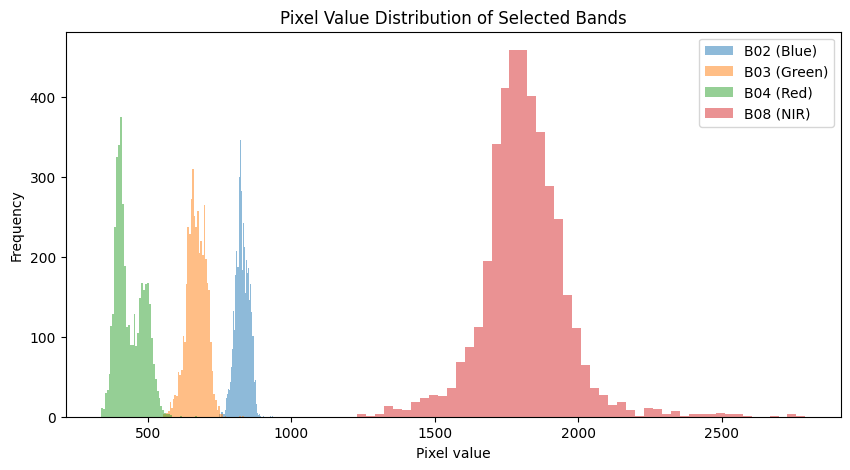

In [14]:
plt.figure(figsize=(10, 5))

selected_bands = {
    "B02 (Blue)": img[1],
    "B03 (Green)": img[2],
    "B04 (Red)": img[3],
    "B08 (NIR)": img[7],
}

for name, band in selected_bands.items():
    plt.hist(band.ravel(), bins=50, alpha=0.5, label=name)

plt.title("Pixel Value Distribution of Selected Bands")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.legend()
plt.show()